# Import liabrarys 

In [116]:
! pip install xgboost


   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
    --------------------------------------- 1.6/72.0 MB 11.8 MB/s eta 0:00:06
   -- ------------------------------------- 4.5/72.0 MB 13.4 MB/s eta 0:00:06
   ---- ----------------------------------- 8.1/72.0 MB 14.9 MB/s eta 0:00:05
   ------- -------------------------------- 12.8/72.0 MB 17.0 MB/s eta 0:00:04
   --------- ------------------------------ 17.3/72.0 MB 18.1 MB/s eta 0:00:04
   ------------ --------------------------- 22.0/72.0 MB 19.1 MB/s eta 0:00:03
   -------------- ------------------------- 26.7/72.0 MB 19.6 MB/s eta 0:00:03
   ----------------- ---------------------- 31.7/72.0 MB 20.2 MB/s eta 0:00:02
   -------------------- ------------------- 36.4/72.0 MB 20.4 MB/s eta 0:00:02
   ----------------------- ---------------- 41.9/72.0 MB 21.1 MB/s eta 0:00:02
   

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,Ridge,Lasso,ElasticNet

# LOad dataset

In [2]:
df = pd.read_csv("C:\\Users\\satyam_07\\Downloads\\99acres_desc.csv")

In [3]:
df

,name,location,description,rate_per_sqft,area_in_sqft,area_type,property_title,property_type,bhk_type,price_in_cr
0,swarnim sentossa,swarnim sentossa,let your dream of owning a flat come true with...,5009.0,2250.0,super,swarnim sentossa,flat,3,NaN
1,scarlet springs,scarlet springs,"scarlet springs is a residential project, offe...",4377.0,1674.0,super,scarlet springs,flat,3,0.73
2,suryansh sanidhya shivalaya,"sarkhej, sarkhej okaf, ahmedabad",suryansh sanidhya shivalaya society now offers...,3931.0,1080.0,super,suryansh sanidhya shivalaya,flat,2,0.42
3,siddhi terrace skyline,memnagar,"siddhi terrace skyline, one of the known housi...",7198.0,2320.0,super,siddhi terrace skyline,flat,3,1.67
4,aadhya arambh,"ghatlodia, ahmedabad","beautiful 3,4 bhk apartments in ghatlodia, are...",NaN,1604.0,carpet,aadhya arambh,flat,4,NaN
...,...,...,...,...,...,...,...,...,...,...
20055,z luxuria,z luxuria,z luxuria is a project by zade group in ahmeda...,17962.0,5400.0,super,z luxuria,flat,7,NaN
20056,hn riviera bliss,"insouth bopal, ahmedabad","hn riviera bliss, one of the known housing soc...",NaN,3121.0,carpet,hn riviera bliss,flat,5,NaN
20057,highline by ag group,"insola, ahmedabad","beautiful 3,4,5 bhk apartments in sola, are no...",NaN,10920.0,super,highline by ag group,flat,5,NaN
20058,goyal riviera prestige,"inmakarba, sg highway","beautiful 3,4,5 bhk apartments in makarba, are...",NaN,2879.0,carpet,goyal riviera prestige,flat,5,NaN


# getting data information

In [4]:
df.columns = df.columns.str.strip()


In [5]:
df.shape

(20060, 10)

In [6]:
df.columns

Index(['name', 'location', 'description', 'rate_per_sqft', 'area_in_sqft',
       'area_type', 'property_title', 'property_type', 'bhk_type',
       'price_in_cr'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20060 entries, 0 to 20059
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   name            19950 non-null  object 
 1   location        19765 non-null  object 
 2   description     20045 non-null  object 
 3   rate_per_sqft   19701 non-null  float64
 4   area_in_sqft    20036 non-null  float64
 5   area_type       20060 non-null  object 
 6   property_title  19949 non-null  object 
 7   property_type   20060 non-null  object 
 8   bhk_type        20060 non-null  int64  
 9   price_in_cr     19332 non-null  float64
dtypes: float64(3), int64(1), object(6)
memory usage: 1.5+ MB


In [8]:
df.describe()

,rate_per_sqft,area_in_sqft,bhk_type,price_in_cr
count,1.970100e+04,2.003600e+04,20060.000000,19332.000000
mean,1.375771e+04,3.123944e+03,2.903988,1.462783
std,2.134984e+05,7.027497e+04,1.207127,2.100932
min,0.000000e+00,1.000000e+00,1.000000,0.010000
25%,4.620000e+03,1.000000e+03,2.000000,0.550000
50%,6.153000e+03,1.500000e+03,3.000000,0.850000
75%,8.860000e+03,2.169000e+03,3.000000,1.550000
max,1.500000e+07,6.534000e+06,45.000000,120.000000


# data manipulaion and preprocessing

In [9]:
df.drop(["name"],axis=1,inplace=True)

In [10]:
df.isnull().sum()

location          295
description        15
rate_per_sqft     359
area_in_sqft       24
area_type           0
property_title    111
property_type       0
bhk_type            0
price_in_cr       728
dtype: int64

In [11]:
df

,location,description,rate_per_sqft,area_in_sqft,area_type,property_title,property_type,bhk_type,price_in_cr
0,swarnim sentossa,let your dream of owning a flat come true with...,5009.0,2250.0,super,swarnim sentossa,flat,3,NaN
1,scarlet springs,"scarlet springs is a residential project, offe...",4377.0,1674.0,super,scarlet springs,flat,3,0.73
2,"sarkhej, sarkhej okaf, ahmedabad",suryansh sanidhya shivalaya society now offers...,3931.0,1080.0,super,suryansh sanidhya shivalaya,flat,2,0.42
3,memnagar,"siddhi terrace skyline, one of the known housi...",7198.0,2320.0,super,siddhi terrace skyline,flat,3,1.67
4,"ghatlodia, ahmedabad","beautiful 3,4 bhk apartments in ghatlodia, are...",NaN,1604.0,carpet,aadhya arambh,flat,4,NaN
...,...,...,...,...,...,...,...,...,...
20055,z luxuria,z luxuria is a project by zade group in ahmeda...,17962.0,5400.0,super,z luxuria,flat,7,NaN
20056,"insouth bopal, ahmedabad","hn riviera bliss, one of the known housing soc...",NaN,3121.0,carpet,hn riviera bliss,flat,5,NaN
20057,"insola, ahmedabad","beautiful 3,4,5 bhk apartments in sola, are no...",NaN,10920.0,super,highline by ag group,flat,5,NaN
20058,"inmakarba, sg highway","beautiful 3,4,5 bhk apartments in makarba, are...",NaN,2879.0,carpet,goyal riviera prestige,flat,5,NaN


In [12]:
def extract_price(text):
    if pd.isnull(text):
        return None

    text = text.lower()

    # crore
    cr_match = re.search(r'(\d+\.?\d*)\s*cr', text)
    if cr_match:
        return float(cr_match.group(1))

    # lakh / lac
    lakh_match = re.search(r'(\d+\.?\d*)\s*(lakh|lac)', text)
    if lakh_match:
        return float(lakh_match.group(1)) / 100  # lakh to crore

    return None

In [13]:
df['price_from_desc'] = df['description'].apply(extract_price)


In [14]:
df['price_in_cr'] = df['price_in_cr'].fillna(df['price_from_desc'])


In [15]:
df.drop(columns=['price_from_desc'], inplace=True)


In [16]:
df.isnull().sum()

location          295
description        15
rate_per_sqft     359
area_in_sqft       24
area_type           0
property_title    111
property_type       0
bhk_type            0
price_in_cr       404
dtype: int64

In [17]:
df['price_in_cr'].fillna(df['price_in_cr'].median(), inplace=True)


C:\Users\satyam_07\AppData\Local\Temp\ipykernel_4884\3180200188.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['price_in_cr'].fillna(df['price_in_cr'].median(), inplace=True)


In [18]:
df.isnull().sum()

location          295
description        15
rate_per_sqft     359
area_in_sqft       24
area_type           0
property_title    111
property_type       0
bhk_type            0
price_in_cr         0
dtype: int64

In [19]:
group_median = df.groupby(
    ['location', 'bhk_type']
)['price_in_cr'].transform('median')

df['price_in_cr'] = df['price_in_cr'].fillna(group_median)


In [20]:
df.isnull().sum()

location          295
description        15
rate_per_sqft     359
area_in_sqft       24
area_type           0
property_title    111
property_type       0
bhk_type            0
price_in_cr         0
dtype: int64

In [21]:
df['area_in_sqft'].fillna(df['area_in_sqft'].median(), inplace=True)


C:\Users\satyam_07\AppData\Local\Temp\ipykernel_4884\4067546379.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['area_in_sqft'].fillna(df['area_in_sqft'].median(), inplace=True)


In [22]:
df.isnull().sum()

location          295
description        15
rate_per_sqft     359
area_in_sqft        0
area_type           0
property_title    111
property_type       0
bhk_type            0
price_in_cr         0
dtype: int64

In [23]:
df['rate_per_sqft'].fillna(df['rate_per_sqft'].median(), inplace=True)


C:\Users\satyam_07\AppData\Local\Temp\ipykernel_4884\783511365.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['rate_per_sqft'].fillna(df['rate_per_sqft'].median(), inplace=True)


In [24]:
df.isnull().sum()

location          295
description        15
rate_per_sqft       0
area_in_sqft        0
area_type           0
property_title    111
property_type       0
bhk_type            0
price_in_cr         0
dtype: int64

In [25]:
df["location"] = df["location"].fillna(df["property_title"])

In [26]:
df.isnull().sum()

location            9
description        15
rate_per_sqft       0
area_in_sqft        0
area_type           0
property_title    111
property_type       0
bhk_type            0
price_in_cr         0
dtype: int64

In [27]:
df["property_title"] = df["property_title"].fillna(df["location"])


In [28]:
df[df.isnull().any(axis=1)]

,location,description,rate_per_sqft,area_in_sqft,area_type,property_title,property_type,bhk_type,price_in_cr
3225,NaN,NaN,12500.0,11400.0,super,NaN,flat,5,14.25
3227,NaN,NaN,12500.0,16400.0,super,NaN,flat,5,20.50
3278,NaN,NaN,12500.0,11900.0,super,NaN,flat,5,14.88
3281,NaN,NaN,11000.0,12130.0,super,NaN,flat,5,13.34
3411,NaN,NaN,9500.0,11000.0,super,NaN,flat,5,10.45
3449,NaN,NaN,11000.0,24000.0,super,NaN,flat,5,26.40
4986,NaN,NaN,12500.0,11450.0,super,NaN,flat,5,14.31
7113,"inshela, ahmedabad",NaN,6153.0,1500.0,super,vishwanath maher homes 5,flat,2,0.85
7745,NaN,NaN,3804.0,2880.0,super,NaN,flat,3,0.88
11331,NaN,NaN,11000.0,15000.0,super,NaN,flat,6,16.50


In [29]:
df.isnull().sum()

location           9
description       15
rate_per_sqft      0
area_in_sqft       0
area_type          0
property_title     9
property_type      0
bhk_type           0
price_in_cr        0
dtype: int64

In [30]:
df.drop(["description"], axis = 1, inplace = True)

In [31]:
df.drop(["property_title"],axis=1, inplace=True)

In [32]:
df

,location,rate_per_sqft,area_in_sqft,area_type,property_type,bhk_type,price_in_cr
0,swarnim sentossa,5009.0,2250.0,super,flat,3,1.03
1,scarlet springs,4377.0,1674.0,super,flat,3,0.73
2,"sarkhej, sarkhej okaf, ahmedabad",3931.0,1080.0,super,flat,2,0.42
3,memnagar,7198.0,2320.0,super,flat,3,1.67
4,"ghatlodia, ahmedabad",6153.0,1604.0,carpet,flat,4,1.62
...,...,...,...,...,...,...,...
20055,z luxuria,17962.0,5400.0,super,flat,7,0.85
20056,"insouth bopal, ahmedabad",6153.0,3121.0,carpet,flat,5,4.28
20057,"insola, ahmedabad",6153.0,10920.0,super,flat,5,4.53
20058,"inmakarba, sg highway",6153.0,2879.0,carpet,flat,5,2.10


In [33]:
df.nunique()

location         7330
rate_per_sqft    6697
area_in_sqft     2524
area_type           4
property_type       4
bhk_type           17
price_in_cr       737
dtype: int64

# Data is devided in 4 form like super,carpet,built_up,and plot

# 

# Super Dataframe

# 

In [34]:
df["area_type"].unique()

array(['super', 'carpet', 'built-up', 'plot'], dtype=object)

In [35]:
a1, a2, a3, a4 = df['area_type'].unique()

Super = df[df['area_type'] == a1]
carpet = df[df['area_type'] == a2]
built_up = df[df['area_type'] == a3]
plot = df[df['area_type'] == a4]

In [36]:
Super

,location,rate_per_sqft,area_in_sqft,area_type,property_type,bhk_type,price_in_cr
0,swarnim sentossa,5009.0,2250.0,super,flat,3,1.03
1,scarlet springs,4377.0,1674.0,super,flat,3,0.73
2,"sarkhej, sarkhej okaf, ahmedabad",3931.0,1080.0,super,flat,2,0.42
3,memnagar,7198.0,2320.0,super,flat,3,1.67
5,vasna,6153.0,2178.0,super,flat,3,1.33
...,...,...,...,...,...,...,...
20051,skyzenia,4130.0,11090.0,super,flat,5,10.08
20052,highline by ag group,1392.0,10920.0,super,flat,4,4.53
20055,z luxuria,17962.0,5400.0,super,flat,7,0.85
20057,"insola, ahmedabad",6153.0,10920.0,super,flat,5,4.53


In [37]:
Super["price_in_cr"].sum()

np.float64(17515.55)

In [38]:
Super["bhk_type"].count()

np.int64(11893)

In [39]:
Super["bhk_type"].unique()

array([ 3,  2,  4,  5,  6,  8,  1, 12,  7, 18, 16, 11, 10,  9, 34, 45])

In [40]:
bhk_avg_price = (
    Super.groupby('bhk_type')['price_in_cr']
      .mean()
)

print(bhk_avg_price)


bhk_type
1     0.305961
2     0.583824
3     1.180300
4     2.999001
5     5.185029
6     4.448070
7     3.704211
8     4.466154
9     1.616667
10    6.408333
11    3.250000
12    4.750000
16    8.000000
18    5.950000
34    0.850000
45    0.850000
Name: price_in_cr, dtype: float64


In [41]:
bhk_avg_price

bhk_type
1     0.305961
2     0.583824
3     1.180300
4     2.999001
5     5.185029
6     4.448070
7     3.704211
8     4.466154
9     1.616667
10    6.408333
11    3.250000
12    4.750000
16    8.000000
18    5.950000
34    0.850000
45    0.850000
Name: price_in_cr, dtype: float64

# this plots says price,respect to bhk of locations

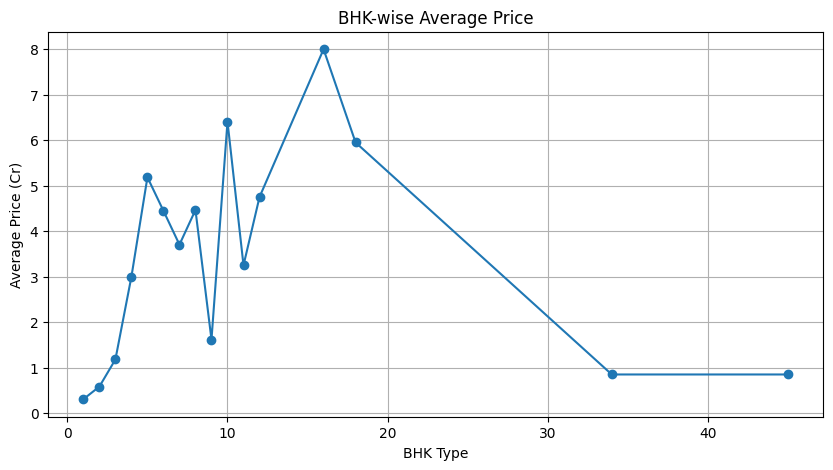

In [42]:
plt.figure(figsize=(10,5))
plt.plot(bhk_avg_price.index, bhk_avg_price.values, marker='o')
plt.xlabel("BHK Type")
plt.ylabel("Average Price (Cr)")
plt.title("BHK-wise Average Price")
plt.grid(True)
plt.show()


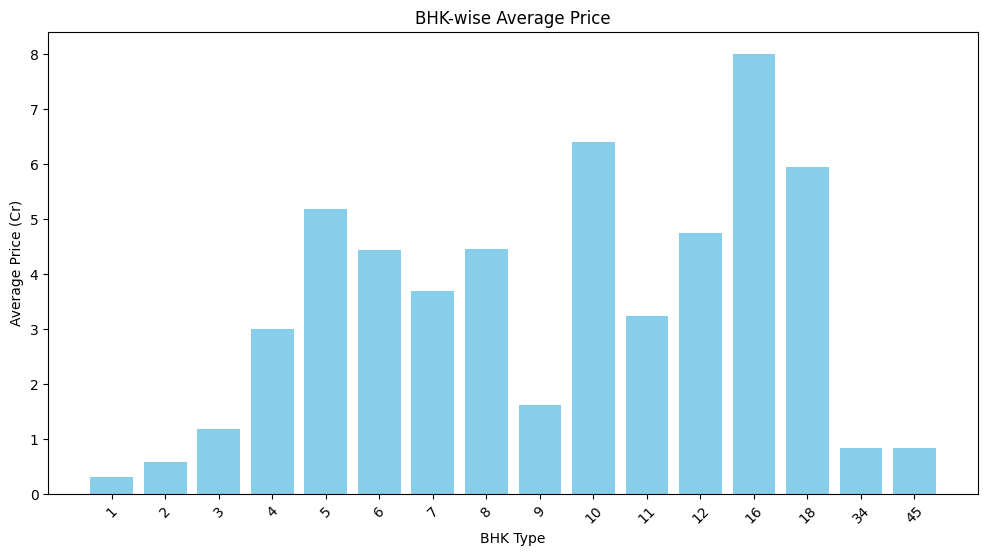

In [43]:
plt.figure(figsize=(12,6))
plt.bar(bhk_avg_price.index.astype(str), bhk_avg_price.values, color='skyblue')
plt.xlabel("BHK Type")
plt.ylabel("Average Price (Cr)")
plt.title("BHK-wise Average Price")
plt.xticks(rotation=45)
plt.show()


In [44]:
def bhk_category(x):
    if x <= 5:
        return 'Normal (1-5 BHK)'
    elif x <= 12:
        return 'Luxury (6-12 BHK)'
    else:
        return 'Ultra Luxury (13+ BHK)'

Super['bhk_category'] = Super['bhk_type'].apply(bhk_category)


C:\Users\satyam_07\AppData\Local\Temp\ipykernel_4884\1400884943.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Super['bhk_category'] = Super['bhk_type'].apply(bhk_category)


In [45]:
category_price = Super.groupby('bhk_category')['price_in_cr'].sum()
category_count = Super.groupby('bhk_category')['bhk_type'].count()
plot_Super = category_price.reset_index()
plot_Super.columns = ['bhk_category', 'total_price']
plot_Super['count'] = category_count.values
print(plot_Super)


             bhk_category  total_price  count
0       Luxury (6-12 BHK)       441.38    104
1        Normal (1-5 BHK)     17051.72  11783
2  Ultra Luxury (13+ BHK)        22.45      6


In [46]:
bhk_cat = plot_Super["bhk_category"]

In [47]:
bhk_cat

0         Luxury (6-12 BHK)
1          Normal (1-5 BHK)
2    Ultra Luxury (13+ BHK)
Name: bhk_category, dtype: object

In [48]:
bhk_pri = plot_Super["total_price"]

In [49]:
bhk_pri

0      441.38
1    17051.72
2       22.45
Name: total_price, dtype: float64

In [50]:
plot_Super = pd.DataFrame({
    'bhk_category': ['Luxury (6-12 BHK)', 'Normal (1-5 BHK)', 'Ultra Luxury (13+ BHK)'],
    'price_in_crore': [441.38, 17051.72, 22.45]
})

print(plot_Super)

             bhk_category  price_in_crore
0       Luxury (6-12 BHK)          441.38
1        Normal (1-5 BHK)        17051.72
2  Ultra Luxury (13+ BHK)           22.45


# This plot says total price normal, luxury and ultra luxury places

C:\Users\satyam_07\AppData\Local\Temp\ipykernel_4884\1870210738.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


Text(0.5, 1.0, 'Total Price per BHK Category')

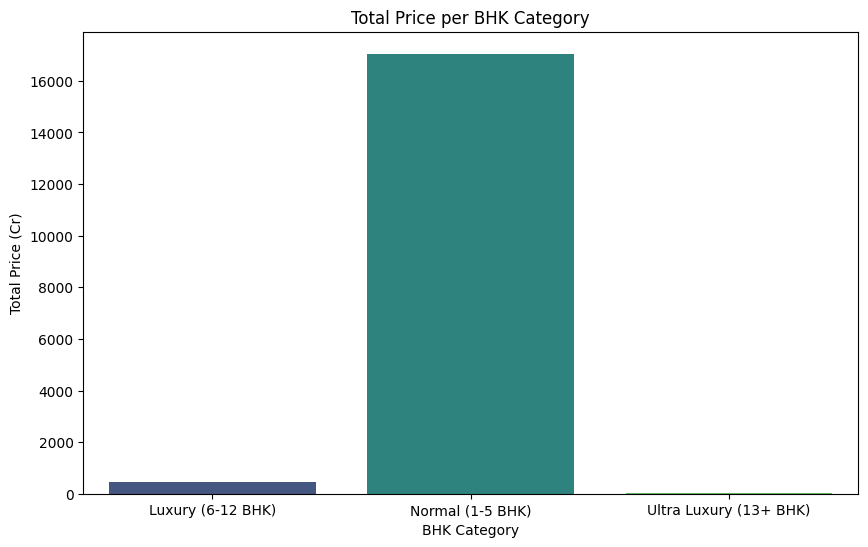

In [51]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=plot_Super,
    x='bhk_category',
    y='price_in_crore',
    palette='viridis'
)
plt.xlabel("BHK Category")
plt.ylabel("Total Price (Cr)")
plt.title("Total Price per BHK Category")

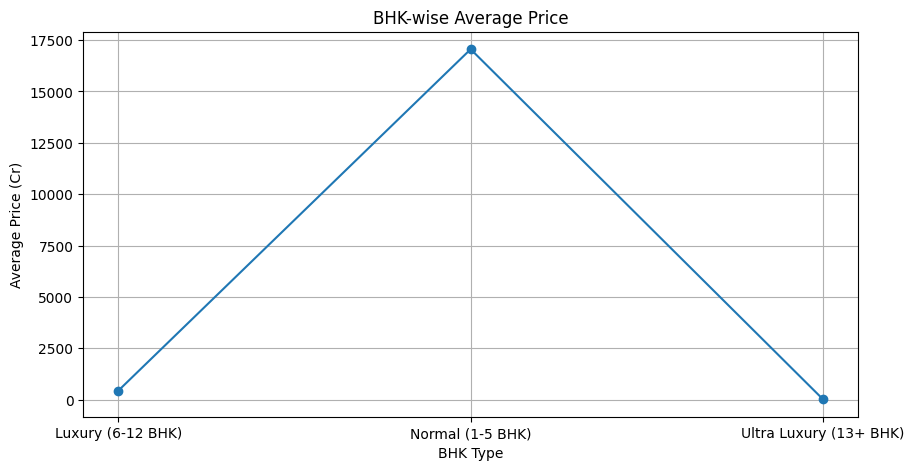

In [52]:
plt.figure(figsize=(10,5))
plt.plot(bhk_cat, bhk_pri, marker='o')
plt.xlabel("BHK Type")
plt.ylabel("Average Price (Cr)")
plt.title("BHK-wise Average Price")
plt.grid(True)
plt.show()

# 

# Carpet

#

In [53]:
carpet

,location,rate_per_sqft,area_in_sqft,area_type,property_type,bhk_type,price_in_cr
4,"ghatlodia, ahmedabad",6153.0,1604.0,carpet,flat,4,1.62
6,"ghatlodia, ahmedabad",10123.0,978.0,carpet,flat,3,0.99
19,"motera, ahmedabad",8061.0,918.0,carpet,flat,3,0.74
26,ghatlodia,6153.0,1604.0,carpet,flat,4,1.62
27,ghatlodia,10123.0,978.0,carpet,flat,3,0.99
...,...,...,...,...,...,...,...
20038,"inmakarba, sg highway",7155.0,2879.0,carpet,flat,4,2.10
20043,"3, 4",6153.0,2496.0,carpet,flat,4,1.83
20053,"3, 4",7155.0,2879.0,carpet,flat,4,2.10
20056,"insouth bopal, ahmedabad",6153.0,3121.0,carpet,flat,5,4.28


In [54]:
carpet["price_in_cr"].sum()

np.float64(2707.3423000000003)

In [55]:
carpet["bhk_type"].count()

np.int64(2151)

In [56]:
carpet["bhk_type"].unique()

array([ 4,  3,  6,  5,  2,  1,  9,  7,  8, 10])

In [57]:
bhk_avg_price = (
    carpet.groupby('bhk_type')['price_in_cr']
      .mean()
)

print(bhk_avg_price)


bhk_type
1      0.277389
2      0.568603
3      1.050514
4      3.329524
5      4.701915
6      7.627143
7      0.900000
8      0.600000
9      0.650000
10    12.500000
Name: price_in_cr, dtype: float64


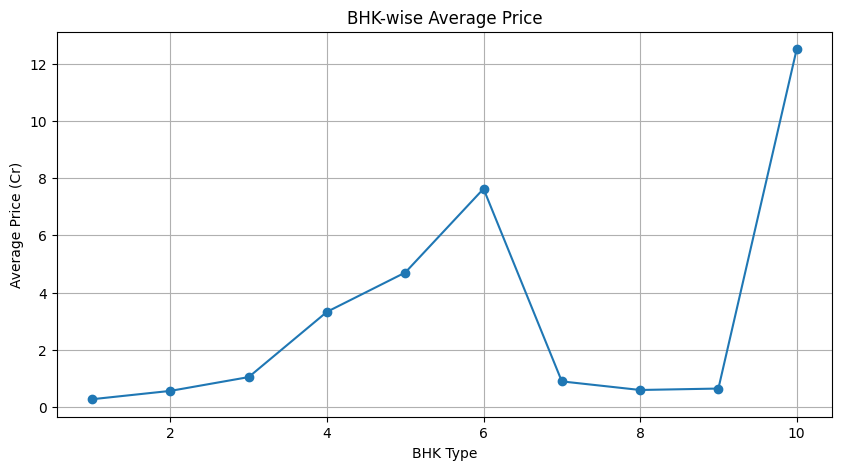

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(bhk_avg_price.index, bhk_avg_price.values, marker='o')
plt.xlabel("BHK Type")
plt.ylabel("Average Price (Cr)")
plt.title("BHK-wise Average Price")
plt.grid(True)
plt.show()


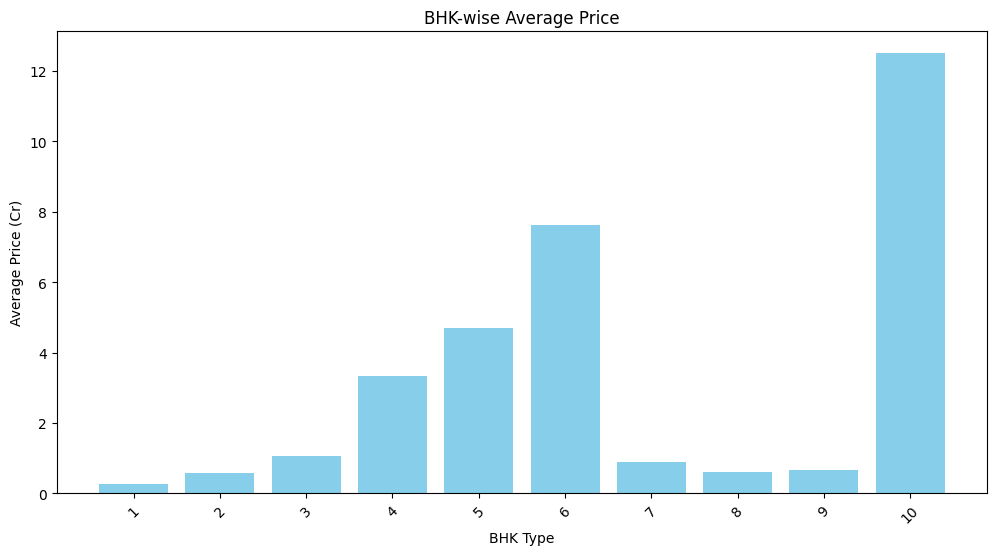

In [59]:
plt.figure(figsize=(12,6))
plt.bar(bhk_avg_price.index.astype(str), bhk_avg_price.values, color='skyblue')
plt.xlabel("BHK Type")
plt.ylabel("Average Price (Cr)")
plt.title("BHK-wise Average Price")
plt.xticks(rotation=45)
plt.show()


In [60]:
def bhk_category(x):
    if x <= 5:
        return 'Normal (1-5 BHK)'
    elif x <= 12:
        return 'Luxury (6-12 BHK)'
    else:
        return 'Ultra Luxury (13+ BHK)'

carpet['bhk_category'] = carpet['bhk_type'].apply(bhk_category)


C:\Users\satyam_07\AppData\Local\Temp\ipykernel_4884\2336595879.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  carpet['bhk_category'] = carpet['bhk_type'].apply(bhk_category)


In [61]:
category_price = carpet.groupby('bhk_category')['price_in_cr'].sum()
category_count = carpet.groupby('bhk_category')['bhk_type'].count()
plot_carpet = category_price.reset_index()
plot_carpet.columns = ['bhk_category', 'total_price']
plot_carpet['count'] = category_count.values
print(plot_carpet)


        bhk_category  total_price  count
0  Luxury (6-12 BHK)      68.9400     12
1   Normal (1-5 BHK)    2638.4023   2139


In [62]:
bhk_cat = plot_carpet["bhk_category"]

In [63]:
bhk_pri = plot_carpet["total_price"]

In [64]:
data = {
    'bhk_category': ['Luxury (6-12 BHK)', 'Normal (1-5 BHK)'],
    'total_price': [68.9400, 2638.4023],
    'count': [12, 2139]
}

# create DataFrame
df_carpet = pd.DataFrame(data)

# check
print(df_carpet)

        bhk_category  total_price  count
0  Luxury (6-12 BHK)      68.9400     12
1   Normal (1-5 BHK)    2638.4023   2139


In [65]:
bhk_cat = plot_carpet["bhk_category"]

In [66]:
bhk_pri = plot_carpet["total_price"]

C:\Users\satyam_07\AppData\Local\Temp\ipykernel_4884\3930580127.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


Text(0.5, 1.0, 'Total Price per BHK Category')

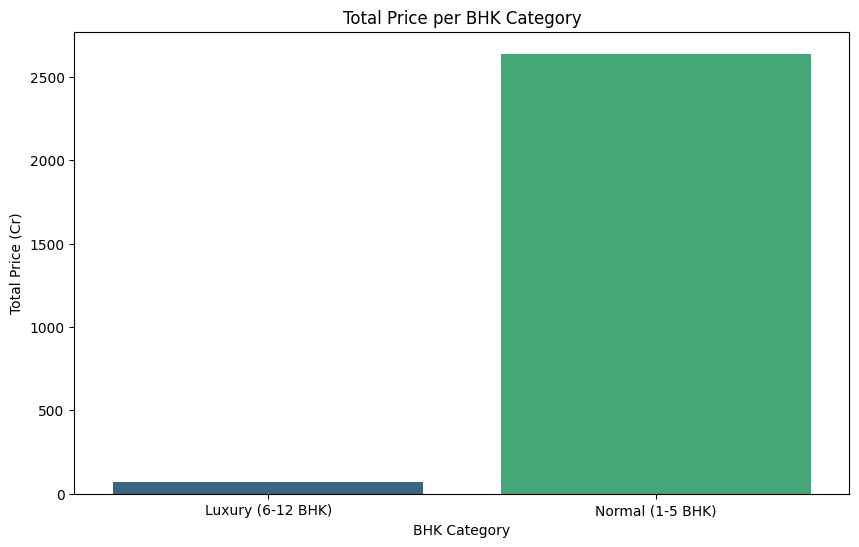

In [67]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=df_carpet,
    x=bhk_cat,
    y=bhk_pri,
    palette='viridis'
)
plt.xlabel("BHK Category")
plt.ylabel("Total Price (Cr)")
plt.title("Total Price per BHK Category")

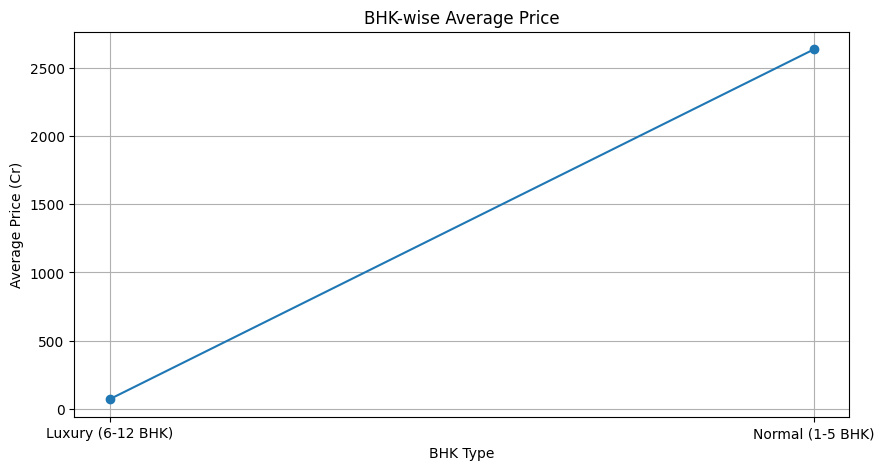

In [68]:
plt.figure(figsize=(10,5))
plt.plot(bhk_cat, bhk_pri, marker='o')
plt.xlabel("BHK Type")
plt.ylabel("Average Price (Cr)")
plt.title("BHK-wise Average Price")
plt.grid(True)
plt.show()

# 

# Built_up Dataframe

# 

In [69]:
built_up

,location,rate_per_sqft,area_in_sqft,area_type,property_type,bhk_type,price_in_cr
11,"kasindra, ahmedabad",3555.0,3798.0,built-up,house,4,1.35
32,kasindra,3555.0,3798.0,built-up,house,4,1.35
51,vaishnodevi circle,7487.0,3406.0,built-up,flat,5,2.55
55,jan,6153.0,1500.0,built-up,house,2,0.70
65,vasna,10515.0,970.0,built-up,flat,3,1.02
...,...,...,...,...,...,...,...
20000,veer savarkar heights 1,5029.0,855.0,built-up,flat,5,0.85
20003,brahmani society,12698.0,1260.0,built-up,flat,5,0.85
20022,"4, 5",7619.0,10500.0,built-up,house,5,8.00
20041,"inadani shantigram, vaishnodevi circle",7619.0,10500.0,built-up,house,6,8.00


In [70]:
built_up["price_in_cr"].sum()
built_up["bhk_type"].count()
built_up["bhk_type"].unique()


array([ 4,  5,  2,  3,  6,  1,  8,  7, 10, 12,  9, 11])

In [71]:
bhk_avg_price = (
    carpet.groupby('bhk_type')['price_in_cr']
      .mean()
)

print(bhk_avg_price)


bhk_type
1      0.277389
2      0.568603
3      1.050514
4      3.329524
5      4.701915
6      7.627143
7      0.900000
8      0.600000
9      0.650000
10    12.500000
Name: price_in_cr, dtype: float64


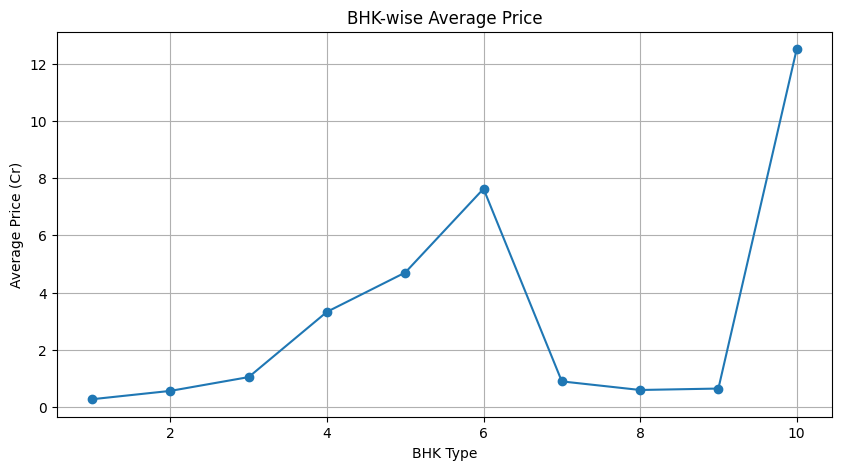

In [72]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(bhk_avg_price.index, bhk_avg_price.values, marker='o')
plt.xlabel("BHK Type")
plt.ylabel("Average Price (Cr)")
plt.title("BHK-wise Average Price")
plt.grid(True)
plt.show()


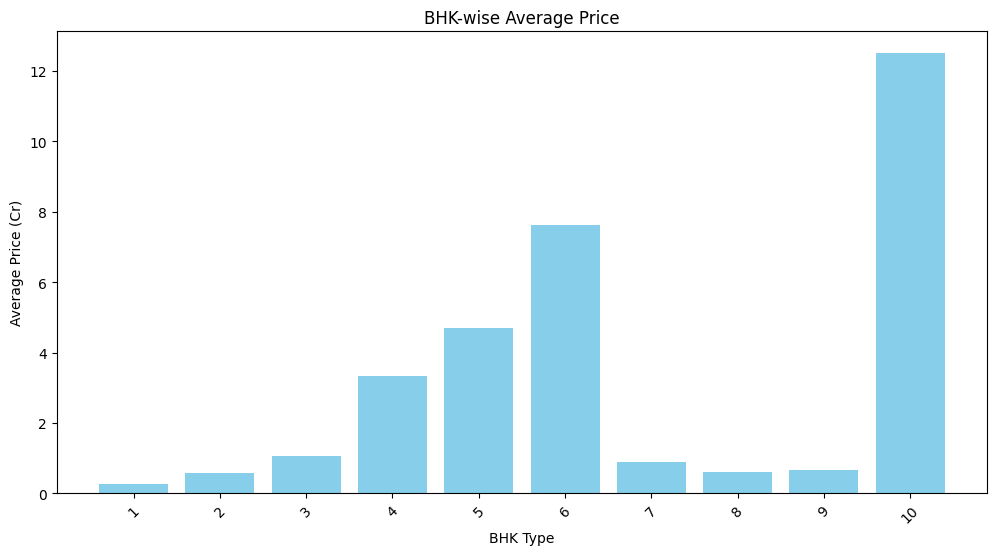

In [73]:
plt.figure(figsize=(12,6))
plt.bar(bhk_avg_price.index.astype(str), bhk_avg_price.values, color='skyblue')
plt.xlabel("BHK Type")
plt.ylabel("Average Price (Cr)")
plt.title("BHK-wise Average Price")
plt.xticks(rotation=45)
plt.show()


In [74]:
def bhk_category(x):
    if x <= 5:
        return 'Normal (1-5 BHK)'
    elif x <= 12:
        return 'Luxury (6-12 BHK)'
    else:
        return 'Ultra Luxury (13+ BHK)'

carpet['bhk_category'] = carpet['bhk_type'].apply(bhk_category)


C:\Users\satyam_07\AppData\Local\Temp\ipykernel_4884\2336595879.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  carpet['bhk_category'] = carpet['bhk_type'].apply(bhk_category)


In [75]:
category_price = carpet.groupby('bhk_category')['price_in_cr'].sum()
category_count = carpet.groupby('bhk_category')['bhk_type'].count()
plot_built_up = category_price.reset_index()
plot_built_up.columns = ['bhk_category', 'total_price']
plot_built_up['count'] = category_count.values
print(plot_built_up)


        bhk_category  total_price  count
0  Luxury (6-12 BHK)      68.9400     12
1   Normal (1-5 BHK)    2638.4023   2139


In [76]:
bhk_cat = plot_built_up["bhk_category"]

In [77]:
bhk_pri = plot_built_up["total_price"]

In [78]:
data = {
    'bhk_category': ['Luxury (6-12 BHK)', 'Normal (1-5 BHK)'],
    'total_price': [68.9400, 2638.4023],
    'count': [12, 2139]
}

# create DataFrame
df_built_up = pd.DataFrame(data)

# check
print(df_built_up)

        bhk_category  total_price  count
0  Luxury (6-12 BHK)      68.9400     12
1   Normal (1-5 BHK)    2638.4023   2139


In [79]:
bhk_cat = plot_built_up["bhk_category"]

In [80]:
bhk_pri = plot_built_up["total_price"]

C:\Users\satyam_07\AppData\Local\Temp\ipykernel_4884\2845116777.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


Text(0.5, 1.0, 'Total Price per BHK Category')

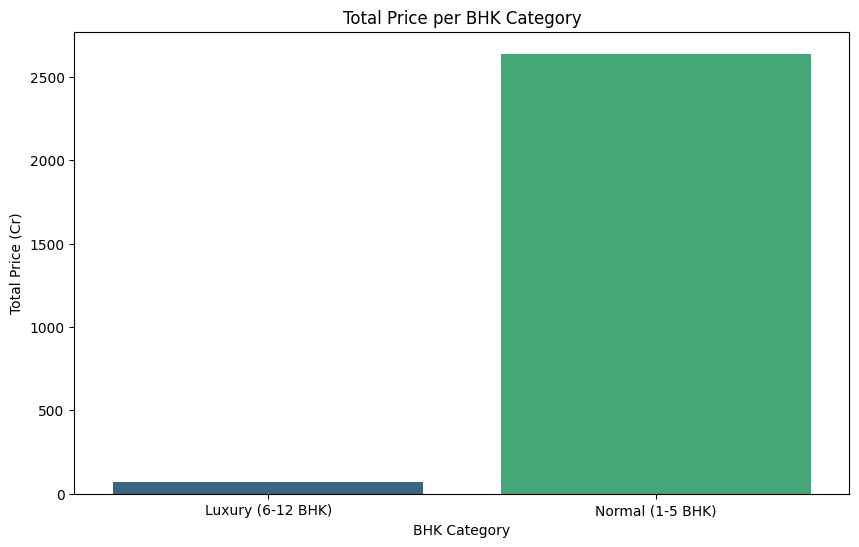

In [81]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=df_built_up,
    x=bhk_cat,
    y=bhk_pri,
    palette='viridis'
)
plt.xlabel("BHK Category")
plt.ylabel("Total Price (Cr)")
plt.title("Total Price per BHK Category")

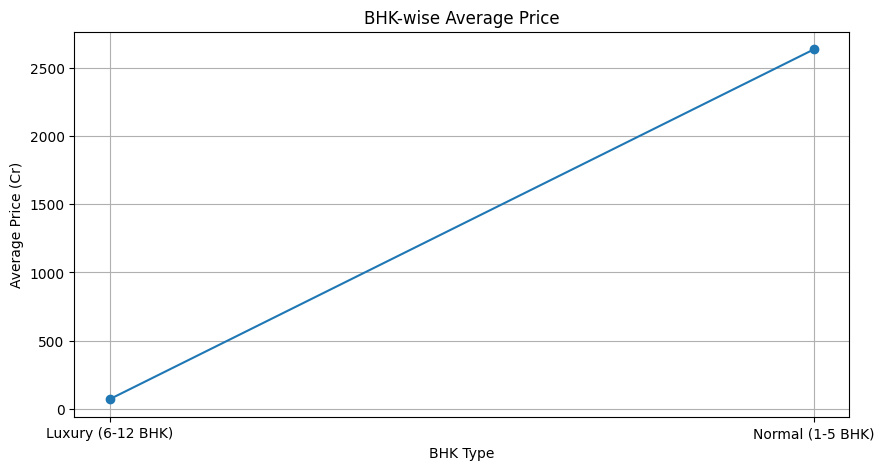

In [82]:
plt.figure(figsize=(10,5))
plt.plot(bhk_cat, bhk_pri, marker='o')
plt.xlabel("BHK Type")
plt.ylabel("Average Price (Cr)")
plt.title("BHK-wise Average Price")
plt.grid(True)
plt.show()

# 

# Plot dataframe

# 

In [83]:
plot

,location,rate_per_sqft,area_in_sqft,area_type,property_type,bhk_type,price_in_cr
132,"c - 24, ami akhand anad - 1",10000.0,1200.0,plot,house,4,1.10
199,"ctm, amraiwadi, ahmedabad, ahmedabad east",14128.0,672.0,plot,land,2,0.95
204,saraswati flate,4600.0,2500.0,plot,land,3,1.15
245,mathrubhumi tenanent nr.dmart,12260.0,1305.0,plot,house,1,1.60
266,"bopal, ahmedabad, ahmedabad west",15833.0,2250.0,plot,land,4,2.85
...,...,...,...,...,...,...,...
19918,"isanpur, ahmedabad, ahmedabad east",8625.0,800.0,plot,flat,2,0.85
19919,"chirag row house, mony hotel road",3517.0,1450.0,plot,house,1,0.85
19922,usmanpuragam,12500.0,1200.0,plot,house,3,1.60
19966,anantara imperial,7926.0,2788.0,plot,flat,4,0.85


In [84]:
plot["price_in_cr"].sum()
plot["bhk_type"].count()
plot["bhk_type"].unique()

array([ 4,  2,  3,  1,  5,  6, 10,  7, 11, 12,  9,  8, 17])

In [85]:
bhk_avg_price = (
    carpet.groupby('bhk_type')['price_in_cr']
      .mean()
)

print(bhk_avg_price)


bhk_type
1      0.277389
2      0.568603
3      1.050514
4      3.329524
5      4.701915
6      7.627143
7      0.900000
8      0.600000
9      0.650000
10    12.500000
Name: price_in_cr, dtype: float64


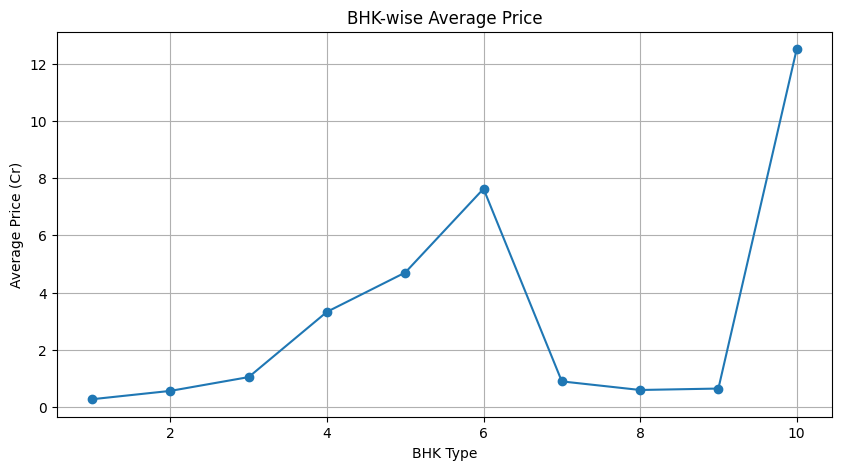

In [86]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(bhk_avg_price.index, bhk_avg_price.values, marker='o')
plt.xlabel("BHK Type")
plt.ylabel("Average Price (Cr)")
plt.title("BHK-wise Average Price")
plt.grid(True)
plt.show()


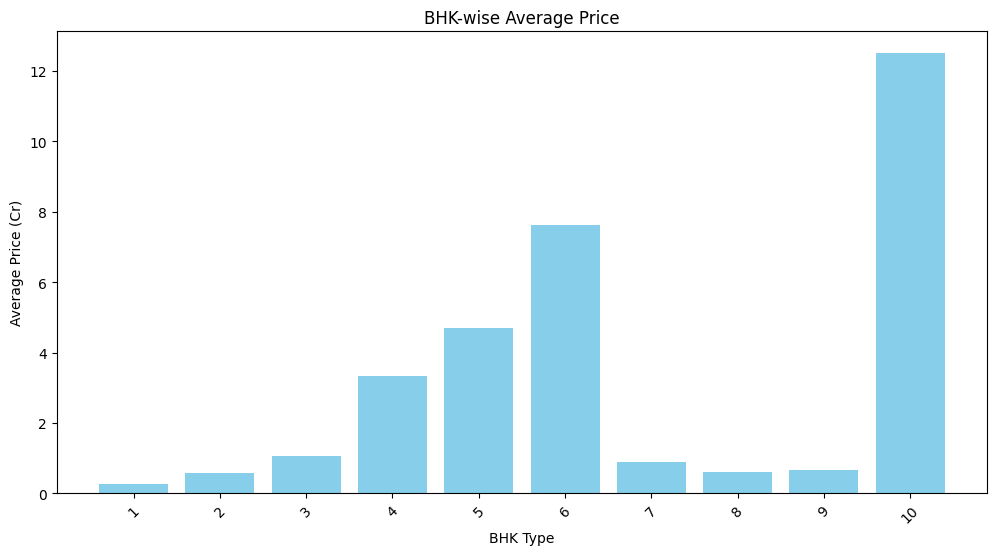

In [87]:
plt.figure(figsize=(12,6))
plt.bar(bhk_avg_price.index.astype(str), bhk_avg_price.values, color='skyblue')
plt.xlabel("BHK Type")
plt.ylabel("Average Price (Cr)")
plt.title("BHK-wise Average Price")
plt.xticks(rotation=45)
plt.show()


In [88]:
def bhk_category(x):
    if x <= 5:
        return 'Normal (1-5 BHK)'
    elif x <= 12:
        return 'Luxury (6-12 BHK)'
    else:
        return 'Ultra Luxury (13+ BHK)'

carpet['bhk_category'] = carpet['bhk_type'].apply(bhk_category)


C:\Users\satyam_07\AppData\Local\Temp\ipykernel_4884\2336595879.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  carpet['bhk_category'] = carpet['bhk_type'].apply(bhk_category)


In [89]:
category_price = carpet.groupby('bhk_category')['price_in_cr'].sum()
category_count = carpet.groupby('bhk_category')['bhk_type'].count()
plot = category_price.reset_index()
plot.columns = ['bhk_category', 'total_price']
plot['count'] = category_count.values
print(plot)


        bhk_category  total_price  count
0  Luxury (6-12 BHK)      68.9400     12
1   Normal (1-5 BHK)    2638.4023   2139


In [90]:
bhk_cat = plot["bhk_category"]

In [91]:
bhk_pri = plot["total_price"]

In [92]:
data = {
    'bhk_category': ['Luxury (6-12 BHK)', 'Normal (1-5 BHK)'],
    'total_price': [68.9400, 2638.4023],
    'count': [12, 2139]
}

# create DataFrame
df_plot = pd.DataFrame(data)

# check
print(df_plot)

        bhk_category  total_price  count
0  Luxury (6-12 BHK)      68.9400     12
1   Normal (1-5 BHK)    2638.4023   2139


In [93]:
bhk_cat = df_plot["bhk_category"]

In [94]:
bhk_pri = df_plot["total_price"]

C:\Users\satyam_07\AppData\Local\Temp\ipykernel_4884\3222032515.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


Text(0.5, 1.0, 'Total Price per BHK Category')

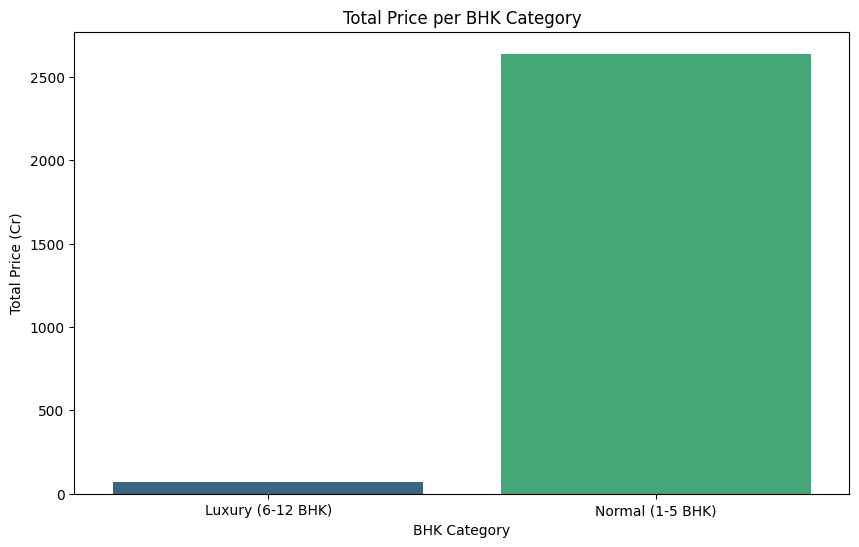

In [95]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=df_plot,
    x=bhk_cat,
    y=bhk_pri,
    palette='viridis'
)
plt.xlabel("BHK Category")
plt.ylabel("Total Price (Cr)")
plt.title("Total Price per BHK Category")

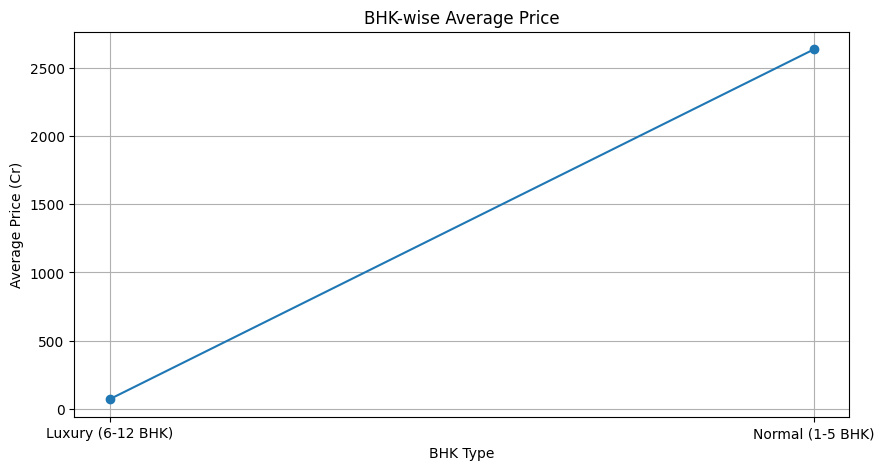

In [96]:
plt.figure(figsize=(10,5))
plt.plot(bhk_cat, bhk_pri, marker='o')
plt.xlabel("BHK Type")
plt.ylabel("Average Price (Cr)")
plt.title("BHK-wise Average Price")
plt.grid(True)
plt.show()

# 

# 

# Apllying machine learning to pridict future prices accorind this dataset

#

#

In [97]:
df

,location,rate_per_sqft,area_in_sqft,area_type,property_type,bhk_type,price_in_cr
0,swarnim sentossa,5009.0,2250.0,super,flat,3,1.03
1,scarlet springs,4377.0,1674.0,super,flat,3,0.73
2,"sarkhej, sarkhej okaf, ahmedabad",3931.0,1080.0,super,flat,2,0.42
3,memnagar,7198.0,2320.0,super,flat,3,1.67
4,"ghatlodia, ahmedabad",6153.0,1604.0,carpet,flat,4,1.62
...,...,...,...,...,...,...,...
20055,z luxuria,17962.0,5400.0,super,flat,7,0.85
20056,"insouth bopal, ahmedabad",6153.0,3121.0,carpet,flat,5,4.28
20057,"insola, ahmedabad",6153.0,10920.0,super,flat,5,4.53
20058,"inmakarba, sg highway",6153.0,2879.0,carpet,flat,5,2.10


In [98]:
df.nunique()

location         7330
rate_per_sqft    6697
area_in_sqft     2524
area_type           4
property_type       4
bhk_type           17
price_in_cr       737
dtype: int64